# Тестовое задание №2

Сгенерировать синтетический датасет для задачи регрессии, построить модель с использованием бэггинга, провести анализ результатов и оценить качество модели.

In [ ]:
# Подключаем необходимые библиотеки
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
# Генерация данных
n_samples = 1000
n_features = 10
coefficients = np.random.randn(n_features)
gauss_noise = 0.2

X = np.random.randn(n_samples, n_features)
y = np.dot(X, coefficients) + gauss_noise * np.random.randn(n_samples)

In [ ]:
# Разделение данных на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
# Построение модели
reg = BaggingRegressor(estimator = LinearRegression()).fit(X_train,y_train)

In [ ]:
# Оценка модели по MSE и R^2
y_pred = reg.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Оценка по метрике MSE: {mse:.4f}')
print(f'Оценка по метрике R^2: {r2:.4f}')

Оценка по метрике MSE: 0.0432
Оценка по метрике R^2: 0.9956


In [ ]:
# Проверка мультиколлинеарности при помощи корреляционной матрицы
feature_names = [f'признак_{i}' for i in range(1, n_features + 1)]
X_train_df = pd.DataFrame(X_train, columns = feature_names)
corr_matrix = X_train_df.corr()
corr_matrix

,признак_1,признак_2,признак_3,признак_4,признак_5,признак_6,признак_7,признак_8,признак_9,признак_10
признак_1,1.000000,-0.006446,0.028990,-0.057785,0.081633,-0.014597,-0.026461,0.009305,0.000446,0.005464
признак_2,-0.006446,1.000000,0.027227,-0.010563,-0.067508,-0.003653,0.032222,0.013889,-0.019158,-0.008539
признак_3,0.028990,0.027227,1.000000,0.015775,-0.023092,0.006475,-0.004708,-0.008088,-0.074448,0.065982
признак_4,-0.057785,-0.010563,0.015775,1.000000,0.044762,-0.006578,0.058433,-0.027996,0.034578,0.045694
признак_5,0.081633,-0.067508,-0.023092,0.044762,1.000000,-0.045899,-0.085395,-0.039359,0.029232,-0.036128
признак_6,-0.014597,-0.003653,0.006475,-0.006578,-0.045899,1.000000,-0.034631,-0.036960,0.025175,0.006866
признак_7,-0.026461,0.032222,-0.004708,0.058433,-0.085395,-0.034631,1.000000,-0.024304,-0.043487,-0.033500
признак_8,0.009305,0.013889,-0.008088,-0.027996,-0.039359,-0.036960,-0.024304,1.000000,-0.016698,-0.025906
признак_9,0.000446,-0.019158,-0.074448,0.034578,0.029232,0.025175,-0.043487,-0.016698,1.000000,0.075688
признак_10,0.005464,-0.008539,0.065982,0.045694,-0.036128,0.006866,-0.033500,-0.025906,0.075688,1.000000


<Axes: >

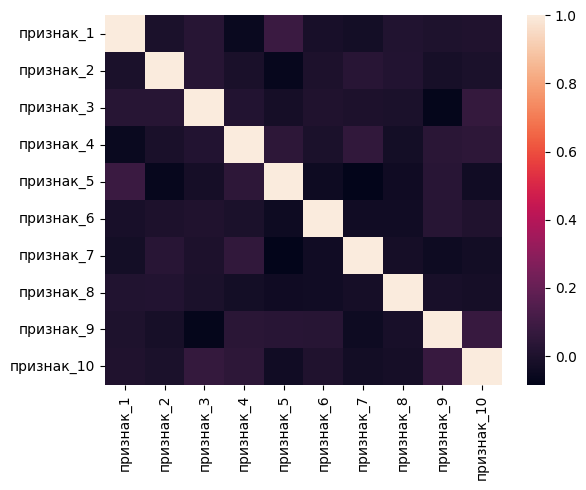

In [ ]:
# Тепловая карта для корреляционной матрицы
sns.heatmap(corr_matrix)

In [ ]:
# Проверка мультиколлинеарности при помощи коэффициента инфляции дисперсии (VIF)
vif_df = pd.DataFrame()
vif_df['feature'] = X_train_df.columns
vif_df['VIF'] = [variance_inflation_factor(X_train_df.values, i) for i in range(n_features)]
print(vif_df)

      feature       VIF
0   признак_1  1.012180
1   признак_2  1.006418
2   признак_3  1.013290
3   признак_4  1.014239
4   признак_5  1.028542
5   признак_6  1.006002
6   признак_7  1.018001
7   признак_8  1.005921
8   признак_9  1.017064
9  признак_10  1.016767


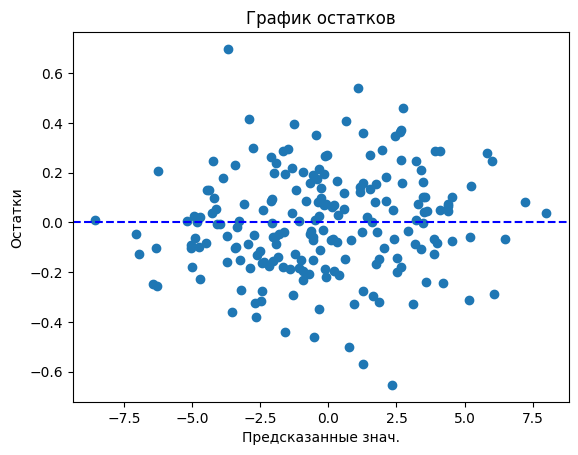

In [ ]:
# Анализ остатков модели. График остатков
remains = y_test - y_pred
plt.scatter(y_pred, remains)
plt.axhline(y=0, color='b', linestyle='--')
plt.xlabel('Предсказанные знач.')
plt.ylabel('Остатки')
plt.title('График остатков')
plt.show()

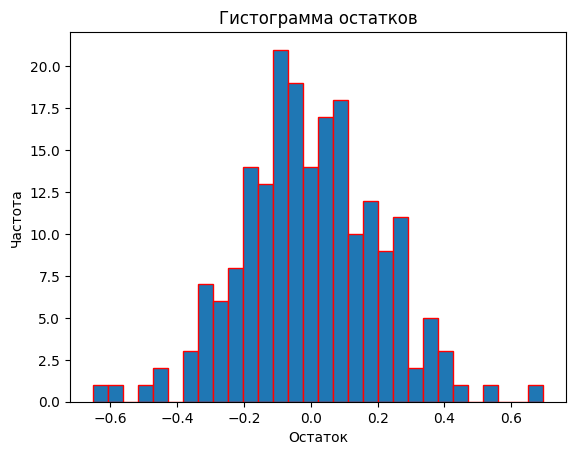

In [ ]:
# Анализ остатков модели. Гистрограмма остатков
plt.hist(remains, bins=30, edgecolor='red')
plt.xlabel('Остаток')
plt.ylabel('Частота')
plt.title('Гистограмма остатков')
plt.show()

# Распределение напоминает нормальное

In [ ]:
# Оценка важности признаков
estimators = reg.estimators_
coeffs = np.array([estimator.coef_ for estimator in estimators])

std_X = X_train.std(axis = 0)
std_y = y_train.std()
beta = coeffs * (std_X / std_y)

importance = np.mean(np.abs(beta), axis = 0)
importance_df = pd.DataFrame({'Признак': feature_names, 'Важность': importance}).sort_values('Важность', ascending=False)
print(importance_df)

      Признак  Важность
9  признак_10  0.616220
0   признак_1  0.523224
4   признак_5  0.379325
3   признак_4  0.365722
6   признак_7  0.247957
7   признак_8  0.118545
2   признак_3  0.115656
5   признак_6  0.075919
8   признак_9  0.068425
1   признак_2  0.006409
